임베딩 + BM25 + RRF 하이브리드 검색 미니 실습

1. 데이터 준비

In [83]:
!pip install datasets

In [84]:
!pip install sentence-transformers faiss-cpu

In [85]:
!pip install rank_bm25 transformers

In [86]:
from datasets import load_dataset

# KLUE-MRC train split 로드
dataset = load_dataset("klue", "mrc", split="train")

print(dataset)

Dataset({
    features: ['title', 'context', 'news_category', 'source', 'guid', 'is_impossible', 'question_type', 'question', 'answers'],
    num_rows: 17554
})


In [87]:
print(dataset[0])

{'title': '제주도 장마 시작 … 중부는 이달 말부터', 'context': '올여름 장마가 17일 제주도에서 시작됐다. 서울 등 중부지방은 예년보다 사나흘 정도 늦은 이달 말께 장마가 시작될 전망이다.17일 기상청에 따르면 제주도 남쪽 먼바다에 있는 장마전선의 영향으로 이날 제주도 산간 및 내륙지역에 호우주의보가 내려지면서 곳곳에 100㎜에 육박하는 많은 비가 내렸다. 제주의 장마는 평년보다 2~3일, 지난해보다는 하루 일찍 시작됐다. 장마는 고온다습한 북태평양 기단과 한랭 습윤한 오호츠크해 기단이 만나 형성되는 장마전선에서 내리는 비를 뜻한다.장마전선은 18일 제주도 먼 남쪽 해상으로 내려갔다가 20일께 다시 북상해 전남 남해안까지 영향을 줄 것으로 보인다. 이에 따라 20~21일 남부지방에도 예년보다 사흘 정도 장마가 일찍 찾아올 전망이다. 그러나 장마전선을 밀어올리는 북태평양 고기압 세력이 약해 서울 등 중부지방은 평년보다 사나흘가량 늦은 이달 말부터 장마가 시작될 것이라는 게 기상청의 설명이다. 장마전선은 이후 한 달가량 한반도 중남부를 오르내리며 곳곳에 비를 뿌릴 전망이다. 최근 30년간 평균치에 따르면 중부지방의 장마 시작일은 6월24~25일이었으며 장마기간은 32일, 강수일수는 17.2일이었다.기상청은 올해 장마기간의 평균 강수량이 350~400㎜로 평년과 비슷하거나 적을 것으로 내다봤다. 브라질 월드컵 한국과 러시아의 경기가 열리는 18일 오전 서울은 대체로 구름이 많이 끼지만 비는 오지 않을 것으로 예상돼 거리 응원에는 지장이 없을 전망이다.', 'news_category': '종합', 'source': 'hankyung', 'guid': 'klue-mrc-v1_train_12759', 'is_impossible': False, 'question_type': 1, 'question': '북태평양 기단과 오호츠크해 기단이 만나 국내에 머무르는 기간은?', 'answers': {'answer_start': [478, 478], 'text'

In [88]:
subset = dataset.select(range(200))

# 문단 (검색 대상)
corpus = [item['context'] for item in subset]

# 질문 (쿼리)
queries = []
for i in range(min(3, len(subset))):
    queries.append(subset[i]['question'])

print("문단 개수:", len(corpus))
print("예시 질문:", queries)

문단 개수: 200
예시 질문: ['북태평양 기단과 오호츠크해 기단이 만나 국내에 머무르는 기간은?', '성공적인 성과를 보인 지역SW서비스사업화 지원사업의 주최자는?', '지능형 생산자동화 기반기술을 개발중인 스타트업은?']


### 오류 설명 및 해결

이전에 발생했던 `TypeError: string indices must be integers, not 'str'` 오류는 `queries` 리스트를 생성하는 과정에서 `item['question']`과 같이 딕셔너리의 키를 사용하여 값에 접근하려고 할 때, 실제 `item`이 딕셔너리가 아닌 문자열로 인식되어서 발생했습니다.

`datasets` 라이브러리의 `Dataset` 객체에서 슬라이싱 (`subset[:3]`)을 하거나 이를 `list()`로 변환할 때, 내부적으로 각 요소가 예상대로 딕셔너리로 처리되지 않고 다른 형태로 전달될 수 있는 상황이 발생할 수 있습니다.

이를 해결하기 위해 코드를 다음과 같이 수정했습니다:

```python
queries = []
for i in range(min(3, len(subset))):
    queries.append(subset[i]['question'])
```

`for` 루프와 정수 인덱싱 (`subset[i]`)을 사용하여 `Dataset`의 각 요소를 하나씩 가져오도록 변경함으로써, `subset[i]`가 항상 올바른 딕셔너리 객체를 반환하도록 보장했습니다. 이 방법을 통해 `'question'` 키에 안전하게 접근할 수 있게 되어 오류가 해결되었습니다.

In [89]:
corpus = list(set(corpus))
print("중복 제거 후 문단 개수:", len(corpus))

중복 제거 후 문단 개수: 126


In [90]:
print("문단 예시:\n", corpus[0][:200])
print("\n질문 예시:\n", queries[0])

문단 예시:
 박근혜 대통령 당선인은 “법인세를 올려 기업 활동을 위축시키는 데 찬성하지 않는다”고 9일 밝혔다. 또 “(기업의) 상속 문제는 현장의 목소리를 (대통령직 인수위원회에) 충분히 전달하겠다”고 말했다.박 당선인은 이날 오전 대한상공회의소에서 손경식 대한상의 회장을 비롯한 상공인 대표단과의 회동에서 “신뢰할 수 있는 정책으로 여러분이 안심하고 기업 활동에 전념

질문 예시:
 북태평양 기단과 오호츠크해 기단이 만나 국내에 머무르는 기간은?


In [91]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("snunlp/KR-SBERT-V40K-klueNLI-augSTS")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: snunlp/KR-SBERT-V40K-klueNLI-augSTS
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [92]:
import numpy as np

corpus_embeddings = model.encode(corpus, convert_to_numpy=True)

print("임베딩 shape:", corpus_embeddings.shape)

임베딩 shape: (126, 768)


In [93]:
import faiss

dim = corpus_embeddings.shape[1]

index = faiss.IndexFlatIP(dim)

index.add(corpus_embeddings)

print("총 벡터 개수:" , index.ntotal)

총 벡터 개수: 126


In [94]:
def dense_search(query, top_k=5):
    # 쿼리 임베딩
    query_embedding = model.encode([query], convert_to_numpy=True)

    distances, indices = index.search(query_embedding, top_k)

    return indices[0], distances[0]

In [95]:
for query in queries:
    print(f"\n🔍 Query: {query}")

    indices, distances = dense_search(query, top_k=5)

    for i, idx in enumerate(indices):
        print(f"\nRank {i+1}")
        print(f"Distance: {distances[i]:.4f}")
        print(corpus[idx][:200])


🔍 Query: 북태평양 기단과 오호츠크해 기단이 만나 국내에 머무르는 기간은?

Rank 1
Distance: 71.9917
지온공국의 모빌슈트로서는 최초로 빔 라이플을 장비한 기체로 차기 주력 MS 자리를 놓고 걍과 경합, 성능 면에서 이를 압도하고 주력기로서 채용되었다. 각종 빔 병기 및 실드 장비 등 연방측의 병기 건담의 영향을 강하게 받은 것으로 보인다.

스펙 상의 기체 성능은 건담을 약간 상회하며, 이 기체의 양산이 몇 개월만 빨랐어도 일년전쟁의 결말이 변했을지 모른다

Rank 2
Distance: 69.8481
“아폴로우주선을 타고 지금까지 여섯 차례에 걸쳐 12명이 달 표면에 발을 디뎠습니다. 그럼 가장 깊은 바다라고 하는 마리아나 해구의 챌린저 해연(깊이 1만911±40ｍ)까지 내려간 사람은 몇 명일까요? 세 명입니다. 그것도 1960년과 2012년 두 차례뿐이죠.” 지난 18일 경기 안산시에 있는 한국해양과학기술원에서 만난 강정극 원장(사진)은 “우주에 비해

Rank 3
Distance: 68.2901
태평양 전쟁 중 뉴기니 방면에서 진공 작전을 실시해 온 더글러스 맥아더 장군을 사령관으로 하는 미 육군 주체의 연합군 남서 태평양 방면군은 1944년 후반 마침내 필리핀을 진공하기로 결정했다. 그 첫 단계로 필리핀 방면의 전략 거점의 확보가 필요하였으며, 뉴기니 서쪽에 위치한 말루쿠 제도의 모로타이 섬을 공격 목표로 정했다. 또한 동시에 팔라우 제도의 펠렐

Rank 4
Distance: 67.0408
카를 프리드리히 가우스와 자신의 면식을 통하여 자신의 전신으로 소개에 이어 로이터는 매체에서 경력에 착수하였다. 어떤 시초적 실패들에 불구하고 그의 기업적 영혼은 그가 세계에서 주요 그런 통신사들 중의 하나가 된 로이터 통신을 창립할 때 그를 성공으로 이끌었다.

1848년 독일에서 파리로 달아난 후, 로이터는 훗날의 프랑스 통신사 샤를루이 아바스의 통신사

Rank 5
Distance: 64.6716
사이먼 래틀이 이끄는 베를린필과 함께

BM25 구현 (토크나이저 포함)

In [96]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("klue/roberta-base")

In [97]:
def tokenize(text):
    return tokenizer.tokenize(text)

# corpus 전체 토큰화
tokenized_corpus = [tokenize(doc) for doc in corpus]

print("토큰화 예시:", tokenized_corpus[0][:10])

Token indices sequence length is longer than the specified maximum sequence length for this model (700 > 512). Running this sequence through the model will result in indexing errors


토큰화 예시: ['박근혜', '대통령', '당선인', '##은', '“', '법인세', '##를', '올려', '기업', '활동']


In [98]:
from rank_bm25 import BM25Okapi

bm25 = BM25Okapi(tokenized_corpus)

In [99]:
def bm25_search(query, top_k=5):
    tokenized_query = tokenize(query)

    scores = bm25.get_scores(tokenized_query)

    # 상위 k개 인덱스 추출
    top_indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:top_k]

    return top_indices, [scores[i] for i in top_indices]


In [100]:
for query in queries:
    print(f"\n🔍 Query: {query}")

    indices, scores = bm25_search(query, top_k=5)

    for i, idx in enumerate(indices):
        print(f"\nRank {i+1}")
        print(f"Score: {scores[i]:.4f}")
        print(corpus[idx][:200])


🔍 Query: 북태평양 기단과 오호츠크해 기단이 만나 국내에 머무르는 기간은?

Rank 1
Score: 52.7231
올여름 장마가 17일 제주도에서 시작됐다. 서울 등 중부지방은 예년보다 사나흘 정도 늦은 이달 말께 장마가 시작될 전망이다.17일 기상청에 따르면 제주도 남쪽 먼바다에 있는 장마전선의 영향으로 이날 제주도 산간 및 내륙지역에 호우주의보가 내려지면서 곳곳에 100㎜에 육박하는 많은 비가 내렸다. 제주의 장마는 평년보다 2~3일, 지난해보다는 하루 일찍 시작됐

Rank 2
Score: 22.1298
모두투어자기관리부동산투자회사(이하 모두투어리츠, 대표이사 정상만?서상영)가 10월 28일 이사회를 통해 부산 해운대 소재, 베스트웨스턴해운대호텔 매입을 결정했다고 밝혔다. 증권(전문투자형사모부동산투자신탁)형태로 진행되는 이번 투자는 글로벌브랜드 호텔운영사(베스트웨스턴)와 책임임대차계약을 통해 안전적인 수익 창출을 목표로 최소보장임대료(MRG)기준 6%이상 

Rank 3
Score: 18.7751
경희궁(慶熙宮)은 서울특별시에 있는 조선 시대 궁궐로 광해군 9년(1617년)에 건립한 이후, 10대에 걸쳐 임금이 정사를 보았던 궁궐이다. 서울시에 있는 5대 궁궐 중에서 서쪽에 자리하여 서궐로도 불렀으며, 새문안 대궐, 새문동 대궐, 아주개 대궐이라고도 하였다. 조선의 이궁(離宮)으로, 경운궁(덕수궁)과 홍교로 연결되어 있었다. 부지 7만 2천 8백 평

Rank 4
Score: 16.0299
메디컬TV는 6.25 70주년을 맞아 한국전쟁 당시 의료지원국으로 참전한 스칸디나비아3국의 이야기를 담은 특집 다큐멘터리 <유틀란디아호의 항해>를 방송한다. 특히 이 다큐멘터리를 통해 꼬마외교관으로 잘 알려진 캠벨 에이시아가 출연해 의료지원국들의 활약상을 소개하고 참전용사와 그 자손들에게 대한민국 국민의 마음을 담은 감사인사를 전달한다. 1951년 1월 2

Rank 5
Score: 15.0629
부산시와 (재)부산정보산업진흥원(원장 이인숙)이 ‘2020~20

RRF

In [101]:
def reciprocal_rank_fusion(rankings, k=60):
    scores = {}

    for rank_list in rankings:  # [dense 결과, bm25 결과]
        for rank, doc_id in enumerate(rank_list):
            if doc_id not in scores:
                scores[doc_id] = 0
            scores[doc_id] += 1 / (k + rank)

    # 점수 기준 정렬
    sorted_docs = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    return [doc_id for doc_id, _ in sorted_docs]

In [102]:
def hybrid_search(query, top_k=5):
    # Dense 결과
    dense_indices, _ = dense_search(query, top_k=top_k)

    # BM25 결과
    bm25_indices, _ = bm25_search(query, top_k=top_k)

    # RRF 적용
    combined = reciprocal_rank_fusion([dense_indices, bm25_indices])

    return combined[:top_k], dense_indices, bm25_indices

In [103]:
from rank_bm25 import BM25Okapi

bm25 = BM25Okapi(tokenized_corpus)

In [104]:
for query in queries:
    print(f"\n==============================")
    print(f"🔍 Query: {query}")

    # bm25 변수명 변경하여 전역 BM25Okapi 객체를 덮어쓰지 않도록 합니다.
    hybrid, dense, bm25_result_indices = hybrid_search(query, top_k=5)

    print("\n📌 Dense 결과")
    for i, idx in enumerate(dense):
        print(f"\nRank {i+1}")
        print(corpus[idx][:150])

    print("\n📌 BM25 결과")
    # 여기도 변경된 변수명 사용
    for i, idx in enumerate(bm25_result_indices):
        print(f"\nRank {i+1}")
        print(corpus[idx][:150])

    print("\n📌 RRF (Hybrid) 결과")
    for i, idx in enumerate(hybrid):
        print(f"\nRank {i+1}")
        print(corpus[idx][:150])


🔍 Query: 북태평양 기단과 오호츠크해 기단이 만나 국내에 머무르는 기간은?

📌 Dense 결과

Rank 1
지온공국의 모빌슈트로서는 최초로 빔 라이플을 장비한 기체로 차기 주력 MS 자리를 놓고 걍과 경합, 성능 면에서 이를 압도하고 주력기로서 채용되었다. 각종 빔 병기 및 실드 장비 등 연방측의 병기 건담의 영향을 강하게 받은 것으로 보인다.

스펙 상의 기체 성능은 건담

Rank 2
“아폴로우주선을 타고 지금까지 여섯 차례에 걸쳐 12명이 달 표면에 발을 디뎠습니다. 그럼 가장 깊은 바다라고 하는 마리아나 해구의 챌린저 해연(깊이 1만911±40ｍ)까지 내려간 사람은 몇 명일까요? 세 명입니다. 그것도 1960년과 2012년 두 차례뿐이죠.” 지난

Rank 3
태평양 전쟁 중 뉴기니 방면에서 진공 작전을 실시해 온 더글러스 맥아더 장군을 사령관으로 하는 미 육군 주체의 연합군 남서 태평양 방면군은 1944년 후반 마침내 필리핀을 진공하기로 결정했다. 그 첫 단계로 필리핀 방면의 전략 거점의 확보가 필요하였으며, 뉴기니 서쪽에

Rank 4
카를 프리드리히 가우스와 자신의 면식을 통하여 자신의 전신으로 소개에 이어 로이터는 매체에서 경력에 착수하였다. 어떤 시초적 실패들에 불구하고 그의 기업적 영혼은 그가 세계에서 주요 그런 통신사들 중의 하나가 된 로이터 통신을 창립할 때 그를 성공으로 이끌었다.

18

Rank 5
사이먼 래틀이 이끄는 베를린필과 함께 ‘클래식계의 퍼스트레이디’도 한국을 찾는다. 래틀의 부인이자 세계적 메조소프라노인 막달레나 코제나(40·사진)는 오는 19일 서울 서초동 예술의전당 콘서트홀에서 프리바테 무지케 앙상블과 함께 첫 독주회를 연다.체코 브르노에서 태어난

📌 BM25 결과

Rank 1
올여름 장마가 17일 제주도에서 시작됐다. 서울 등 중부지방은 예년보다 사나흘 정도 늦은 이달 말께 장마가 시작될 전망이다.17일 기상청에 따르면 제주도 남쪽 먼바다에 있는 장마전선의 영향으로 이날 제주도 산간 및 내륙지역에 호우

In [105]:
import pandas as pd

def compare_search_rankings(query_string, top_k=5):
    # 하이브리드 검색 실행하여 각 방법의 결과 인덱스 가져오기
    hybrid_indices, dense_indices, bm25_indices = hybrid_search(query_string, top_k=top_k)

    # 결과를 저장할 리스트 초기화
    results = []

    # 각 랭크별로 문서 내용 추출
    for i in range(top_k):
        row = {
            'Rank': i + 1,
            'Dense_Result': corpus[dense_indices[i]][:150] if i < len(dense_indices) else '',
            'BM25_Result': corpus[bm25_indices[i]][:150] if i < len(bm25_indices) else '',
            'Hybrid_Result': corpus[hybrid_indices[i]][:150] if i < len(hybrid_indices) else ''
        }
        results.append(row)

    # DataFrame으로 변환
    df_results = pd.DataFrame(results)
    print(f"\n🔍 Query: {query_string}")
    print("\n--- Top-{top_k} Search Results Comparison ---")
    display(df_results)

# 예시로 첫 번째 쿼리를 사용하여 시각화
compare_search_rankings(queries[0])


🔍 Query: 북태평양 기단과 오호츠크해 기단이 만나 국내에 머무르는 기간은?

--- Top-{top_k} Search Results Comparison ---


,Rank,Dense_Result,BM25_Result,Hybrid_Result
0,1,지온공국의 모빌슈트로서는 최초로 빔 라이플을 장비한 기체로 차기 주력 MS 자리를 ...,올여름 장마가 17일 제주도에서 시작됐다. 서울 등 중부지방은 예년보다 사나흘 정도...,지온공국의 모빌슈트로서는 최초로 빔 라이플을 장비한 기체로 차기 주력 MS 자리를 ...
1,2,“아폴로우주선을 타고 지금까지 여섯 차례에 걸쳐 12명이 달 표면에 발을 디뎠습니다...,"모두투어자기관리부동산투자회사(이하 모두투어리츠, 대표이사 정상만?서상영)가 10월 ...",올여름 장마가 17일 제주도에서 시작됐다. 서울 등 중부지방은 예년보다 사나흘 정도...
2,3,태평양 전쟁 중 뉴기니 방면에서 진공 작전을 실시해 온 더글러스 맥아더 장군을 사령...,경희궁(慶熙宮)은 서울특별시에 있는 조선 시대 궁궐로 광해군 9년(1617년)에 건...,“아폴로우주선을 타고 지금까지 여섯 차례에 걸쳐 12명이 달 표면에 발을 디뎠습니다...
3,4,카를 프리드리히 가우스와 자신의 면식을 통하여 자신의 전신으로 소개에 이어 로이터는...,메디컬TV는 6.25 70주년을 맞아 한국전쟁 당시 의료지원국으로 참전한 스칸디나비...,"모두투어자기관리부동산투자회사(이하 모두투어리츠, 대표이사 정상만?서상영)가 10월 ..."
4,5,사이먼 래틀이 이끄는 베를린필과 함께 ‘클래식계의 퍼스트레이디’도 한국을 찾는다. ...,부산시와 (재)부산정보산업진흥원(원장 이인숙)이 ‘2020~2021년 지역SW서비스...,태평양 전쟁 중 뉴기니 방면에서 진공 작전을 실시해 온 더글러스 맥아더 장군을 사령...


### 검색 결과 관련도 시각화

특정 쿼리에 대해 각 검색 방법(Dense, BM25, Hybrid)이 실제 정답 문서(Relevant Document)를 `top_k` 결과 내에 포함하는지 여부를 시각화합니다. '1'은 해당 문서를 찾았음을 의미하고, '0'은 찾지 못했음을 의미합니다.

Relevant document index for query '북태평양 기단과 오호츠크해 기단이 만나 국내에 머무르는 기간은?' in corpus: 63


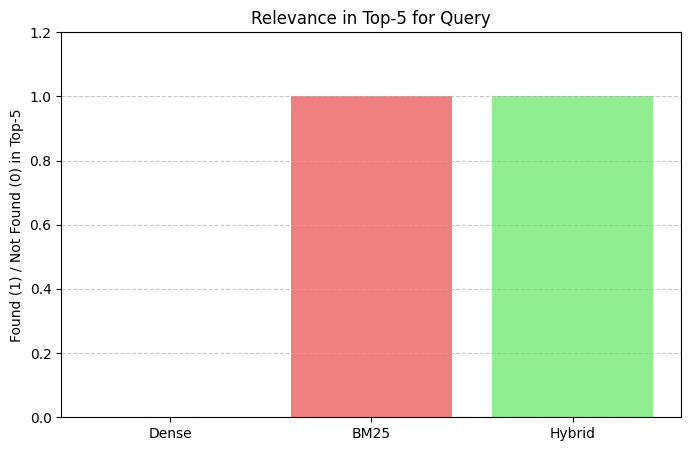

In [110]:
import matplotlib.pyplot as plt

def plot_relevance_comparison(query_string, relevant_doc_id, top_k=5):
    # 각 검색 방법의 결과 인덱스 가져오기
    hybrid_indices, dense_indices, bm25_indices = hybrid_search(query_string, top_k=top_k)

    # 관련 문서가 top_k 결과에 포함되었는지 확인
    dense_found = relevant_doc_id in dense_indices[:top_k]
    bm25_found = relevant_doc_id in bm25_indices[:top_k]
    hybrid_found = relevant_doc_id in hybrid_indices[:top_k]

    labels = ["Dense", "BM25", "Hybrid"]
    scores = [int(dense_found), int(bm25_found), int(hybrid_found)]

    plt.figure(figsize=(8, 5))
    plt.bar(labels, scores, color=['skyblue', 'lightcoral', 'lightgreen'])
    plt.title(f"Relevance in Top-{top_k} for Query")
    plt.ylabel(f"Found (1) / Not Found (0) in Top-{top_k}")
    plt.ylim(0, 1.2)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# 첫 번째 쿼리 (queries[0])에 대한 실제 정답 문서의 인덱스를 찾습니다.
# 'dataset[0]['context']'는 'queries[0]'의 정답 컨텍스트입니다.
original_context_q0 = dataset[0]['context']
relevant_doc_id_q0 = -1
for i, doc in enumerate(corpus):
    if doc == original_context_q0:
        relevant_doc_id_q0 = i
        break

print(f"Relevant document index for query '{queries[0]}' in corpus: {relevant_doc_id_q0}")

# 찾은 관련 문서 ID를 사용하여 첫 번째 쿼리의 관련도 비교를 시각화합니다.
plot_relevance_comparison(queries[0], relevant_doc_id_q0)